# Paper Evaluation Notebook: Retrieval + Generation

This notebook runs the QBrain benchmark and exports paper-ready tables/figures.


In [1]:
from pathlib import Path
import subprocess
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
elif ROOT.name != "rag_lab":
    # fallback for direct execution from repo root
    ROOT = Path("d:/Qbrainpython/QBrain/rag_lab")

OUT_DIR = ROOT / "data" / "outputs" / "evaluation" / "rag_benchmark"
RESULTS_TABLES = ROOT / "results" / "tables"
RESULTS_FIGS = ROOT / "results" / "figures"

RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
RESULTS_FIGS.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("OUT_DIR:", OUT_DIR)


ROOT: D:\Qbrainpython\QBrain\rag_lab
OUT_DIR: D:\Qbrainpython\QBrain\rag_lab\data\outputs\evaluation\rag_benchmark


## 1) Run benchmark
Adjust parameters if needed (`k`, `threshold`, `max_questions_per_srs`).


In [2]:
cmd = [
    sys.executable,
    str(ROOT / "scripts" / "run_rag_benchmark.py"),
    "--k", "5",
    "--threshold", "0.72",
    "--max-questions-per-srs", "10",
]

print("Running:", " ".join(cmd))
proc = subprocess.run(cmd, cwd=str(ROOT), capture_output=True, text=True)
print(proc.stdout)
if proc.returncode != 0:
    print(proc.stderr)
    raise RuntimeError("Benchmark failed")


Running: C:\Users\ahmad\AppData\Local\Programs\Python\Python313\python.exe D:\Qbrainpython\QBrain\rag_lab\scripts\run_rag_benchmark.py --k 5 --threshold 0.72 --max-questions-per-srs 10


Saved benchmark outputs to: D:\Qbrainpython\QBrain\rag_lab\data\outputs\evaluation\rag_benchmark

Overall summary:
                        metric     value
                    srs_files  5.000000
                    questions 45.000000
              retrieval_hit@5  1.000000
        retrieval_precision@5  0.200000
           retrieval_recall@5  1.000000
                retrieval_mrr  1.000000
generation_accuracy_sim>=0.72  0.666667
    generation_avg_similarity  0.784377
             e2e_success_rate  0.666667



## 2) Load outputs


In [3]:
overall = pd.read_csv(OUT_DIR / "overall_summary.csv")
retrieval_srs = pd.read_csv(OUT_DIR / "retrieval" / "retrieval_summary_by_srs.csv")
generation_srs = pd.read_csv(OUT_DIR / "generation" / "generation_summary_by_srs.csv")
e2e_srs = pd.read_csv(OUT_DIR / "e2e" / "e2e_summary_by_srs.csv")
failure_breakdown = pd.read_csv(OUT_DIR / "diagnostics" / "failure_breakdown.csv")
metrics_by_category = pd.read_csv(OUT_DIR / "diagnostics" / "metrics_by_category.csv")

display(overall)
display(retrieval_srs)
display(generation_srs)
display(e2e_srs)


,metric,value
0,srs_files,5.000000
1,questions,45.000000
2,retrieval_hit@5,1.000000
3,retrieval_precision@5,0.200000
4,retrieval_recall@5,1.000000
5,retrieval_mrr,1.000000
6,generation_accuracy_sim>=0.72,0.666667
7,generation_avg_similarity,0.784377
8,e2e_success_rate,0.666667


,srs_file,questions,hit_rate,precision_at_k,recall_at_k,mrr
0,2007 - ertms.pdf,10,1.0,0.2,1.0,1.0
1,2008 - keepass.pdf,10,1.0,0.2,1.0,1.0
2,2009 - inventory 2.0.pdf,10,1.0,0.2,1.0,1.0
3,2010 - gparted.pdf,5,1.0,0.2,1.0,1.0
4,JDECo_SRS.docx[1].pdf,10,1.0,0.2,1.0,1.0


,srs_file,questions,answer_accuracy,avg_similarity,min_similarity,max_similarity
0,2007 - ertms.pdf,10,0.9,0.858133,0.679673,0.929973
1,2008 - keepass.pdf,10,0.6,0.730015,0.551773,0.844432
2,2009 - inventory 2.0.pdf,10,0.6,0.764776,0.658512,0.927734
3,2010 - gparted.pdf,5,0.6,0.806353,0.637482,0.926378
4,JDECo_SRS.docx[1].pdf,10,0.6,0.773596,0.590293,0.955415


,srs_file,questions,e2e_success_rate,retrieval_hit_rate,generation_accuracy
0,2007 - ertms.pdf,10,0.9,1.0,0.9
1,2008 - keepass.pdf,10,0.6,1.0,0.6
2,2009 - inventory 2.0.pdf,10,0.6,1.0,0.6
3,2010 - gparted.pdf,5,0.6,1.0,0.6
4,JDECo_SRS.docx[1].pdf,10,0.6,1.0,0.6


## 3) Build paper tables


In [4]:
overall_map = {row['metric']: row['value'] for _, row in overall.iterrows()}
paper_overall = pd.DataFrame([
    ["Retrieval Hit@5", overall_map.get("retrieval_hit@5", None)],
    ["Retrieval Precision@5", overall_map.get("retrieval_precision@5", None)],
    ["Retrieval Recall@5", overall_map.get("retrieval_recall@5", None)],
    ["Retrieval MRR", overall_map.get("retrieval_mrr", None)],
    ["Generation Accuracy (sim >= 0.72)", overall_map.get("generation_accuracy_sim>=0.72", None)],
    ["Generation Avg Similarity", overall_map.get("generation_avg_similarity", None)],
    ["End-to-End Success Rate", overall_map.get("e2e_success_rate", None)],
], columns=["Metric", "Value"])

paper_overall.to_csv(RESULTS_TABLES / "paper_overall_results.csv", index=False)

paper_per_srs = e2e_srs.merge(
    retrieval_srs[["srs_file", "hit_rate"]], on="srs_file", how="left"
).merge(
    generation_srs[["srs_file", "answer_accuracy"]], on="srs_file", how="left"
)

paper_per_srs = paper_per_srs[["srs_file", "hit_rate", "answer_accuracy", "e2e_success_rate"]]
paper_per_srs.columns = ["SRS File", "Retrieval Hit@5", "Generation Accuracy", "E2E Success"]
paper_per_srs.to_csv(RESULTS_TABLES / "paper_per_srs_results.csv", index=False)

display(paper_overall)
display(paper_per_srs)


,Metric,Value
0,Retrieval Hit@5,1.000000
1,Retrieval Precision@5,0.200000
2,Retrieval Recall@5,1.000000
3,Retrieval MRR,1.000000
4,Generation Accuracy (sim >= 0.72),0.666667
5,Generation Avg Similarity,0.784377
6,End-to-End Success Rate,0.666667


,SRS File,Retrieval Hit@5,Generation Accuracy,E2E Success
0,2007 - ertms.pdf,1.0,0.9,0.9
1,2008 - keepass.pdf,1.0,0.6,0.6
2,2009 - inventory 2.0.pdf,1.0,0.6,0.6
3,2010 - gparted.pdf,1.0,0.6,0.6
4,JDECo_SRS.docx[1].pdf,1.0,0.6,0.6


## 4) Export LaTeX tables


In [5]:
latex_overall = paper_overall.to_latex(index=False, float_format=lambda x: f"{x:.4f}")
latex_per_srs = paper_per_srs.to_latex(index=False, float_format=lambda x: f"{x:.4f}")

(RESULTS_TABLES / "paper_overall_results.tex").write_text(latex_overall, encoding="utf-8")
(RESULTS_TABLES / "paper_per_srs_results.tex").write_text(latex_per_srs, encoding="utf-8")

print(latex_overall)
print("Saved .tex files in", RESULTS_TABLES)


\begin{tabular}{lr}
\toprule
Metric & Value \\
\midrule
Retrieval Hit@5 & 1.0000 \\
Retrieval Precision@5 & 0.2000 \\
Retrieval Recall@5 & 1.0000 \\
Retrieval MRR & 1.0000 \\
Generation Accuracy (sim >= 0.72) & 0.6667 \\
Generation Avg Similarity & 0.7844 \\
End-to-End Success Rate & 0.6667 \\
\bottomrule
\end{tabular}

Saved .tex files in D:\Qbrainpython\QBrain\rag_lab\results\tables


## 5) Plot figures for paper


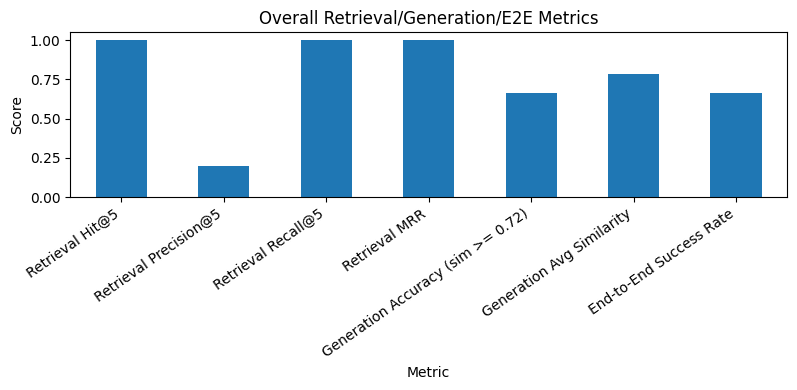

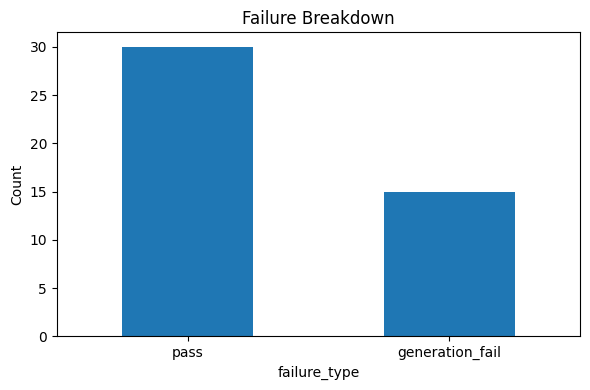

,category,questions,e2e_success_rate,retrieval_hit_rate,generation_accuracy,avg_similarity
0,direct,45,0.666667,1.0,0.666667,0.784377


Saved figures:
- D:\Qbrainpython\QBrain\rag_lab\results\figures\paper_overall_metrics.png
- D:\Qbrainpython\QBrain\rag_lab\results\figures\paper_failure_breakdown.png


In [6]:
plt.figure(figsize=(8, 4))
vals = paper_overall.set_index("Metric")["Value"]
vals.plot(kind="bar")
plt.title("Overall Retrieval/Generation/E2E Metrics")
plt.ylabel("Score")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
fig1 = RESULTS_FIGS / "paper_overall_metrics.png"
plt.savefig(fig1, dpi=200)
plt.show()

plt.figure(figsize=(6, 4))
failure_breakdown.set_index("failure_type")["count"].plot(kind="bar")
plt.title("Failure Breakdown")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
fig2 = RESULTS_FIGS / "paper_failure_breakdown.png"
plt.savefig(fig2, dpi=200)
plt.show()

display(metrics_by_category)
print("Saved figures:")
print("-", fig1)
print("-", fig2)
